In [51]:
#import all necessary libraries
import numpy as np
#import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
from PIL import Image
import struct
from sklearn.linear_model import RidgeClassifier, RidgeClassifierCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedKFold
from sklearn.discriminant_analysis import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
with open('train-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    train_images = np.transpose(data.reshape((size, nrows*ncols)))

with open('train-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    train_labels = data.reshape((size,)) # (Optional)

with open('t10k-images.idx3-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    nrows, ncols = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    test_images = np.transpose(data.reshape((size, nrows*ncols)))
test_images =  np.transpose(test_images).reshape((60000,28, 28)) 

with open('t10k-labels.idx1-ubyte','rb') as f:
    magic, size = struct.unpack(">II", f.read(8))
    data = np.fromfile(f, dtype=np.dtype(np.uint8).newbyteorder('>'))
    test_labels = data.reshape((size,)) # (Optional)
test_labels =  np.transpose(test_labels).reshape((60000,)) 

(47040000,)


(784, 60000)


C:\Users\doria\AppData\Local\Temp\ipykernel_31384\682736504.py:26: DeprecationWarning: 'mode' parameter for changing data types is deprecated and will be removed in Pillow 13 (2026-10-15)
  ax.imshow(Image.fromarray(im, 'L'))


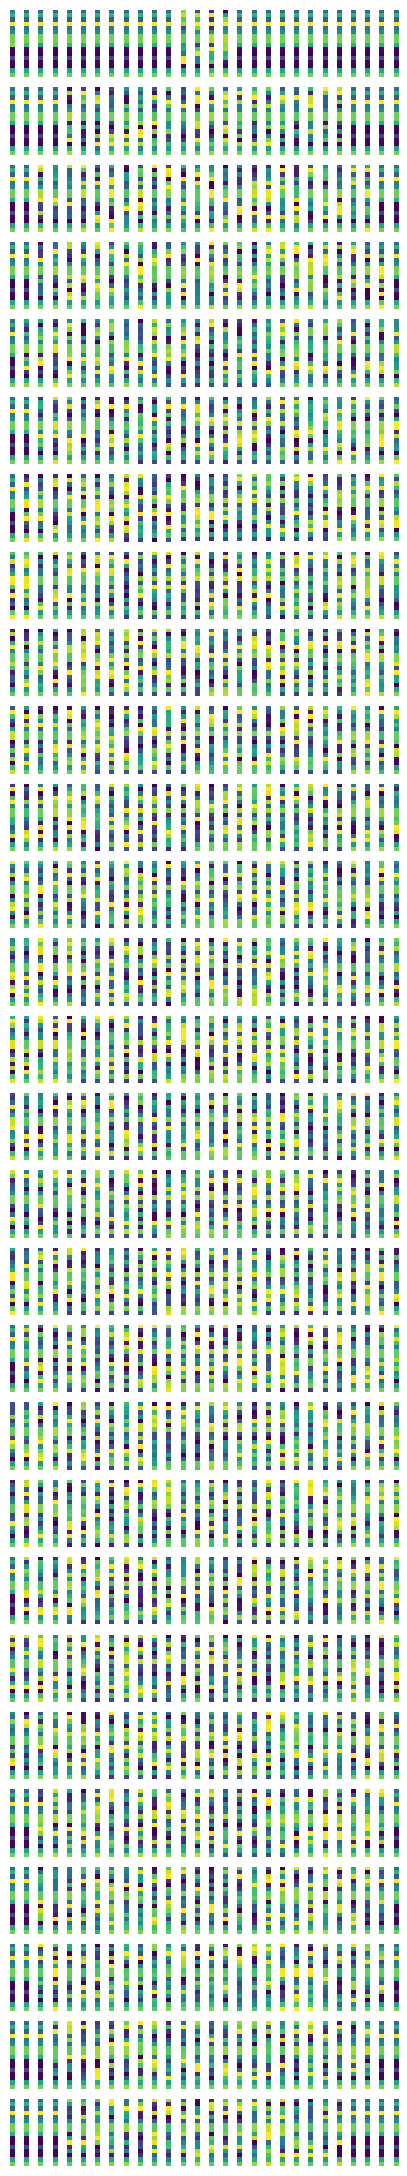

In [65]:
#TASK ONE
# The following code is adapted from https://gist.github.com/akesling/5358964
# The original code is licensed under the MIT License (https://opensource.org/licenses/MIT)
# The original code was written by Andreas Kesling and can be found at https://gist.github.com/akesling/5358964

#Takes a file path to an idx3-ubyte file as a string and returns an array
# of shape (num_images, num_rows, num_cols) containing the images in the file as numpy arrays.
def parse_idx3_ubyte(file_path):
    with open(file_path, 'rb') as f:
        magic, num_images, num_rows, num_cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num_images, num_rows, num_cols)
    return images

#read file and convert into array of images
train_images_file = 'train-images.idx3-ubyte'
#train_images = parse_idx3_ubyte(train_images_file)
print(train_images.shape)

#find first 16 PCA modes of the training data
pca_train = PCA(16).fit_transform(train_images.reshape(train_images.shape[0], -1))

#Plot the first 16 PCA modes as images in a grid
fig = plt.figure(figsize=(28, 28))
grid = ImageGrid(fig, 111, nrows_ncols = (28, 28), axes_pad = 0.1)
for ax, im in zip(grid, pca_train):
    ax.imshow(Image.fromarray(im, 'L'))
    ax.axis('off')

In [69]:
#TASK TWO
##determine the number of PCA modes needed to approximate
###85% of the norm

#initialize vars

train_images =  np.transpose(train_images).reshape((60000,28,28)) 
n = min(train_images[0].shape)
pca_full = PCA(min(train_images[0].shape)).fit(train_images.reshape(train_images.shape[0], -1))
pca_sv = np.sum(pca_full.singular_values_)
pca_full = np.sum(pca_full.singular_values_)

#decrease number of PCA modes until only 85% of the norm is captured
while pca_sv/pca_full > 0.85:
    n = n - 1
    train_pca = PCA(n).fit(train_images.reshape(train_images.shape[0], -1))
    pca_sv = np.sum(train_pca.singular_values_)

#print number of modes required
print(n)

20


In [72]:
#TASK THREE
#takes a file path to an idx1-ubyte file as a string and returns an array of shape (num_items,) 
# containing the labels in the file as numpy arrays.
def parse_idx1_ubyte(file_path):
    with open(file_path, 'rb') as f:
        magic, num_items = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

"""
def choose_digits_img(digits, images):
    selected_images = []
    for digit in digits:
        digit_images = images[images[:, 0] == digit][:1000]
        selected_images.append(digit_images)
    return np.concatenate(selected_images)
"""
#takes a list of digits, an array of labels, and an array of images of the same size, and returns two arrays: 
# one containing the labels of the selected digits and one containing the corresponding images.
def choose_digits_lbl(digits, labels, images):
    selected_labels = []
    selected_images = []
    for digit in digits:
        digit_labels = labels[labels == digit][:1000]
        selected_labels.append(digit_labels)
        digit_images = images[labels == digit][:1000]
        selected_images.append(digit_images)
    return np.concatenate(selected_labels), np.concatenate(selected_images)

#takes a list of digits, an array of labels, and an array of images of the same size for 
# both training and testing data, and returns four arrays: one containing the labels of the selected digits for 
# the training data, one containing the corresponding images for the training data, one containing the labels of 
# the selected digits for the testing data, and one containing the corresponding images for the testing data.
def choose_subsets(digits, x_train, y_train, x_test, y_test):
    y_train, x_train = choose_digits_lbl(digits, y_train, x_train)
    y_test, x_test = choose_digits_lbl(digits, y_test, x_test)
    return x_train, y_train, x_test, y_test

#read in training and testing data and convert into arrays of images and labels
#train labels
train_labels_file = 'train-labels.idx1-ubyte'
train_labels = parse_idx1_ubyte(train_labels_file)

#train images
train_images_file = 'train-images.idx3-ubyte'
train_images = parse_idx3_ubyte(train_images_file)

#test labels
test_labels_file = 't10k-labels.idx1-ubyte'
test_labels = parse_idx1_ubyte(test_labels_file)

#test images
test_images_file = 't10k-images.idx3-ubyte'
test_images = parse_idx3_ubyte(test_images_file)

In [73]:
#TASK FOUR
#Ridge classification

#create training and testing subsets for 1 and 8
x_train, y_train, x_test, y_test = choose_subsets([1, 8], train_images, train_labels, 
                                                  test_images, test_labels)

scaler = StandardScaler()
x_train_scale = scaler.fit_transform(x_train.reshape(x_train.shape[0], -1))
x_test_scale = scaler.transform(x_test.reshape(x_test.shape[0], -1))

#apply PCA to training and testing images
x_train_PCA = train_pca.transform(x_train_scale.reshape(x_train_scale.shape[0], -1))
x_test_PCA = train_pca.transform(x_test_scale.reshape(x_test_scale.shape[0], -1))

#perform ridge classigication with cross validation
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)
alpha_vals = np.logspace(-3, 3, 7)
ridge = RidgeClassifierCV(alphas = alpha_vals, cv=cv)

#fit model and evaluate accuracy
ridge.fit(x_train_PCA, y_train)
y_pred = ridge.predict(x_test_PCA)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9417426545086119


In [ ]:
#TASK FIVE
#Logistic regression

#perform logistic regression and calculate accuracy
logistic = LogisticRegression(penalty = None, solver = 'lbfgs', max_iter=1000)
logistic.fit(x_train_PCA, y_train)
y_pred_logistic = logistic.predict(x_test_PCA)
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
print("Logistic Regression Accuracy:", accuracy_logistic)

Logistic Regression Accuracy: 0.96403242147923


In [ ]:
#TASK SIX
#run regressions for [3, 8] and [2, 7]

#takes a list of digits, training and testing images and labels, and runs ridge classification and logistic 
# regression on the selected digits, printing the accuracy of each model.
def runRegressions(digits, x_train, y_train, x_test, y_test):
    x_train, y_train, x_test, y_test = choose_subsets(digits, x_train, y_train, x_test, y_test)
    x_train_PCA = train_pca.transform(x_train.reshape(x_train.shape[0], -1))
    x_test_PCA = train_pca.transform(x_test.reshape(x_test.shape[0], -1))
    
    scaler= StandardScaler()
    x_train_PCA = scaler.fit_transform(x_train_PCA)
    x_test_PCA = scaler.transform(x_test_PCA)

    ridge = RidgeClassifier(alpha=1.0, solver='auto')
    ridge.fit(x_train_PCA, y_train)
    y_pred_ridge = ridge.predict(x_test_PCA)
    accuracy_ridge = accuracy_score(y_test, y_pred_ridge)
    print("Ridge Classifier Accuracy" + str(digits) + ": " + str(accuracy_ridge))

    logistic = LogisticRegression(max_iter=1000)
    logistic.fit(x_train_PCA, y_train)
    y_pred_logistic = logistic.predict(x_test_PCA)
    accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
    print("Logistic Regression Accuracy" + str(digits) + ": " + str(accuracy_logistic))

#run regressions for [3, 8] and [2, 7]
runRegressions([3, 8], train_images, train_labels, test_images, test_labels)
runRegressions([2, 7], train_images, train_labels, test_images, test_labels)

#TASK SEVEN
#run regressions for all digits
runRegressions(np.arange(10), train_images, train_labels, test_images, test_labels)

Ridge Classifier Accuracy[3, 8]: 0.9518743667679838
Logistic Regression Accuracy[3, 8]: 0.9422492401215805
Ridge Classifier Accuracy[2, 7]: 0.971
Logistic Regression Accuracy[2, 7]: 0.974
Ridge Classifier Accuracy[0 1 2 3 4 5 6 7 8 9]: 0.8517269568771715
Logistic Regression Accuracy[0 1 2 3 4 5 6 7 8 9]: 0.8786020846106684
